# Bridge Diagnostic
Step-by-step inspection: T_eng predictor → bridge ODE → Whisper decode.

In [1]:
import os, sys, json, torch
import numpy as np

os.environ.setdefault('TRAIN_DATA_DIR', '/vol/gpudata/tsv22-train/data/processed/train')
os.environ.setdefault('DEV_DATA_DIR',   '/vol/gpudata/tsv22-dev_test/data/processed/dev')
os.environ.setdefault('TEST_DATA_DIR',  '/vol/gpudata/tsv22-dev_test/data/processed/test')

ROOT = '/vol/gpudata/tsv22-fyp/accent-robust-asr'
sys.path.insert(0, ROOT)
os.chdir(ROOT)

BRIDGE_CKPT    = 'models/bridge_dtw_v2baseline/checkpoint_best.pt'
PREDICTOR_CKPT = 'models/tnat_predictor/model_best.pt'

# Dev pair — has both z_acc and z_nat so we can compare predictor vs GT T_eng
# and measure actual cosine sim to ground-truth native latent
PAIR = {
    "l2_speaker":            "THV",
    "l2_utterance_id":       "arctic_a0313",
    "l2_encoder_state_path": "THV/THV_arctic_a0313.pt",
    "nat_speaker":           "CLB",
    "nat_encoder_state_path":"CLB/CLB_arctic_a0313.pt",
    "l2_speech_end_frame":   193,
    "nat_speech_end_frame":  162,
    "text":                  "Broken Tooth yelled with fright and pain",
    "l1":                    "Vietnamese",
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print(f'Utterance: "{PAIR["text"]}"  |  l2={PAIR["l2_speaker"]}  nat={PAIR["nat_speaker"]}')
N_STEPS = 20  # ODE steps — change here to update throughout notebook


device: cuda
Utterance: "Broken Tooth yelled with fright and pain"  |  l2=THV  nat=CLB


## 1. Load encoder state

In [2]:
from pathlib import Path

dev_dir   = Path(os.environ['DEV_DATA_DIR'])
train_dir = Path(os.environ['TRAIN_DATA_DIR'])

def load_state(rel_path):
    for d in [dev_dir, train_dir]:
        p = d / rel_path
        if p.exists():
            s = torch.load(p, map_location='cpu', weights_only=False)
            return s['hidden_states'].float(), p
    return None, None

z_acc, p_acc = load_state(PAIR['l2_encoder_state_path'])
z_nat, p_nat = load_state(PAIR['nat_encoder_state_path'])

assert z_acc is not None, f"z_acc not found: {PAIR['l2_encoder_state_path']}"
assert z_nat is not None, f"z_nat not found: {PAIR['nat_encoder_state_path']}"

T_l2     = PAIR['l2_speech_end_frame']
T_eng_gt = PAIR['nat_speech_end_frame']

print(f'z_acc loaded from: {p_acc}')
print(f'z_nat loaded from: {p_nat}')
print(f'T_l2={T_l2}  T_eng_gt={T_eng_gt}')
print(f'z_acc speech scale: {z_acc[:T_l2].norm(dim=-1).mean():.3f}')
print(f'z_nat speech scale: {z_nat[:T_eng_gt].norm(dim=-1).mean():.3f}')
cos_baseline = torch.nn.functional.cosine_similarity(
    z_acc[:min(T_l2, T_eng_gt)], z_nat[:min(T_l2, T_eng_gt)], dim=-1).mean()
print(f'Baseline cos_sim(z_acc, z_nat): {cos_baseline:.4f}')

z_acc loaded from: /vol/gpudata/tsv22-train/data/processed/train/THV/THV_arctic_a0313.pt
z_nat loaded from: /vol/gpudata/tsv22-train/data/processed/train/CLB/CLB_arctic_a0313.pt
T_l2=193  T_eng_gt=162
z_acc speech scale: 41.278
z_nat speech scale: 41.411
Baseline cos_sim(z_acc, z_nat): 0.4803


## 2. T_eng predictor

In [3]:
from src.experiments.exp2_latent_diffusion_bridge.eval import load_tnat_predictor
from src.experiments.exp2_latent_diffusion_bridge.train_tnat_predictor import T_NORM
print(f'Loading predictor from {PREDICTOR_CKPT}...')
predictor = load_tnat_predictor(PREDICTOR_CKPT, device)
print(f'Predictor loaded from {PREDICTOR_CKPT}')
z_acc_dev = z_acc.to(device)
with torch.no_grad():
    pool    = z_acc_dev[:T_l2].mean(dim=0, keepdim=True)        # [1, 768]
    t_l2_n  = torch.tensor([T_l2 / T_NORM], device=device)      # [1]
    T_eng_hat_raw = predictor(pool, t_l2_n).item() * T_NORM

T_eng_hat = int(round(T_eng_hat_raw))
T_eng_hat = max(1, min(T_eng_hat, 1500))

print(f'T_l2        : {T_l2}')
print(f'T_eng_hat   : {T_eng_hat}  (raw: {T_eng_hat_raw:.1f})')
print(f'inf_len     : {max(T_l2, T_eng_hat) + 1}')

Loading predictor from models/tnat_predictor/model_best.pt...
Predictor loaded from models/tnat_predictor/model_best.pt
T_l2        : 193
T_eng_hat   : 173  (raw: 172.9)
inf_len     : 194


## 3. Bridge ODE — inspect z_nat_hat

In [4]:
from src.experiments.exp2_latent_diffusion_bridge.eval import load_bridge_model
from src.experiments.exp2_latent_diffusion_bridge.diffusion import bridge_inference

bridge = load_bridge_model(BRIDGE_CKPT, device)
print('parameterization:', bridge.parameterization)

z_acc_bf16 = z_acc.to(device=device, dtype=torch.bfloat16).unsqueeze(0)  # [1, 1500, 768]

# Read sigma_max from config
import json
from pathlib import Path
cfg = json.loads((Path(BRIDGE_CKPT).parent / 'config.json').read_text())
sigma_max = cfg['sigma_max']
print(f'sigma_max: {sigma_max}')

with torch.no_grad():
    z_nat_hat = bridge_inference(
        bridge, z_acc_bf16, T_l2=T_l2, T_nat=T_eng_hat,
        n_steps=N_STEPS, sigma_max=sigma_max, parameterization=bridge.parameterization,
    )  # [1, 1500, 768]

z_nat_hat_cpu = z_nat_hat.squeeze(0).float().cpu()  # [1500, 768]

print(f'\nz_acc  speech scale (frames 0:{T_l2}): {z_acc[:T_l2].norm(dim=-1).mean():.3f}')
print(f'z_hat  speech scale (frames 0:{T_eng_hat}): {z_nat_hat_cpu[:T_eng_hat].norm(dim=-1).mean():.3f}')
print(f'z_hat  tail   scale (frames {T_eng_hat}:): {z_nat_hat_cpu[T_eng_hat:T_eng_hat+20].norm(dim=-1).mean():.3f}')
print(f'z_acc  NaN: {z_acc.isnan().any()},  z_hat NaN: {z_nat_hat_cpu.isnan().any()}')

# Cosine sim of speech frames to z_acc speech frames
a = z_acc[:T_l2]
b = z_nat_hat_cpu[:min(T_l2, T_eng_hat)]
n = min(len(a), len(b))
cos = torch.nn.functional.cosine_similarity(a[:n], b[:n], dim=-1).mean()
print(f'\ncos_sim(z_hat_speech, z_acc_speech): {cos:.4f}')

parameterization: x0
sigma_max: 0.3

z_acc  speech scale (frames 0:193): 41.278
z_hat  speech scale (frames 0:173): 38.007
z_hat  tail   scale (frames 173:): 37.851
z_acc  NaN: False,  z_hat NaN: False

cos_sim(z_hat_speech, z_acc_speech): 0.9107


## 4. Per-step ODE trace — watch how z_t evolves

In [5]:
# Manually step through the ODE to see if it diverges
B, L, D = z_acc_bf16.shape
dtype = z_acc_bf16.dtype

sil      = z_acc_bf16[:, T_l2:T_l2 + 1, :].clone()
inf_len  = max(T_l2, T_eng_hat) + 1
z_acc_crop = z_acc_bf16[:, :inf_len, :]
t_schedule = torch.linspace(1.0, 0.0, N_STEPS + 1, device=device, dtype=dtype)

def apply_mask(z, t):
    N_t = max(1, round(float(t) * T_l2 + (1 - float(t)) * T_eng_hat))
    N_t = min(N_t, L)
    z[:, N_t:, :] = sil.expand(B, L - N_t, D)
    return z

z_t = z_acc_bf16.clone()
z_t = apply_mask(z_t, 1.0)

is_cfm = bridge.parameterization == 'cfm'
bridge.eval()
print(f'{"step":>4}  {"t":>5}  {"N(t)":>5}  {"z_t_scale":>11}  {"z_hat_scale":>12}  {"vel_norm":>10}  {"vel_step":>10}')
with torch.no_grad():
    for i in range(N_STEPS):
        t_cur  = t_schedule[i]
        t_next = t_schedule[i + 1]
        dt     = (t_cur - t_next).item()
        N_t    = max(1, round(float(t_cur) * T_l2 + (1 - float(t_cur)) * T_eng_hat))

        t_batch  = torch.full((B,), t_cur, device=device, dtype=dtype)
        out_crop = bridge(z_t[:, :inf_len, :], t_batch, z_acc_crop)

        if is_cfm:
            vel_norm       = out_crop.float().norm(dim=-1).mean().item()
            vel_step       = (out_crop * dt).float().norm(dim=-1).mean().item()
            z_nat_hat_crop = z_t[:, :inf_len, :] - out_crop * dt   # Euler step
        elif bridge.parameterization == 'x0':
            vel_norm, vel_step = float('nan'), float('nan')
            z_nat_hat_crop = out_crop
        else:  # eps
            vel_norm, vel_step = float('nan'), float('nan')
            sigma_fwd      = sigma_max * torch.sqrt(torch.clamp(t_cur, min=1e-5))
            z_nat_hat_crop = z_t[:, :inf_len, :] - sigma_fwd * out_crop

        z_t_scale  = z_t[0, :N_t, :].float().norm(dim=-1).mean().item()
        zhat_scale = z_nat_hat_crop[0, :N_t, :].float().norm(dim=-1).mean().item()
        vn = f'{vel_norm:>10.3f}' if vel_norm == vel_norm else f'{"—":>10}'
        vs = f'{vel_step:>10.3f}' if vel_step == vel_step else f'{"—":>10}'
        print(f'{i:>4}  {t_cur.item():>5.3f}  {N_t:>5}  {z_t_scale:>11.3f}  {zhat_scale:>12.3f}  {vn}  {vs}')

        if i == N_STEPS - 1:
            break

        if is_cfm:
            z_t[:, :inf_len, :] = z_nat_hat_crop
        else:
            z_nat_hat_full = z_t.clone()
            z_nat_hat_full[:, :inf_len, :] = z_nat_hat_crop
            z_t = (1 - t_next / t_cur) * z_nat_hat_full + (t_next / t_cur) * z_t
        z_t = apply_mask(z_t, t_next.item())


step      t   N(t)    z_t_scale   z_hat_scale    vel_norm    vel_step
   0  1.000    193       41.278        32.838           —           —
   1  0.949    192       40.537        34.148           —           —
   2  0.898    191       39.894        35.576           —           —
   3  0.852    190       39.440        36.227           —           —
   4  0.801    189       39.058        36.758           —           —
   5  0.750    188       38.729        37.116           —           —
   6  0.699    187       38.456        37.339           —           —
   7  0.648    186       38.231        37.511           —           —
   8  0.602    185       38.063        37.628           —           —
   9  0.547    184       37.900        37.720           —           —
  10  0.500    183       37.818        37.802           —           —
  11  0.451    182       37.767        37.876           —           —
  12  0.400    181       37.713        37.897           —           —
  13  0.350    180  

## 5. Whisper decode — z_acc baseline vs z_nat_hat

In [6]:
from transformers.modeling_outputs import BaseModelOutput
from src.utils.model_loader import load_baseline_whisper

whisper_model, processor = load_baseline_whisper()
whisper_model = whisper_model.to(device).eval()

def decode(z: torch.Tensor, label: str):
    enc_out = BaseModelOutput(last_hidden_state=z.unsqueeze(0).to(device))
    with torch.no_grad():
        ids = whisper_model.generate(encoder_outputs=enc_out, language='en',
                                      task='transcribe', temperature=0.0)
    text = processor.batch_decode(ids, skip_special_tokens=True)[0]
    print(f'[{label}] "{text}"')
    return text

print(f'Reference: "{PAIR["text"]}"\n')
decode(z_acc.to(torch.float32),       'z_acc (accented, no bridge)')
decode(z_nat_hat_cpu.to(torch.float32), 'z_nat_hat (bridge output)')

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensA

Reference: "Broken Tooth yelled with fright and pain"

[z_acc (accented, no bridge)] " Broke the top with a fried egg"
[z_nat_hat (bridge output)] " Roe can toot yell with fright and ban."


' Roe can toot yell with fright and ban.'

## 6. Try with GT T_eng (bypass predictor)

In [7]:
print(f'T_eng_gt={T_eng_gt}  T_eng_hat={T_eng_hat}  (error: {abs(T_eng_hat - T_eng_gt)} frames)\n')

with torch.no_grad():
    z_hat_gt = bridge_inference(
        bridge, z_acc_bf16, T_l2=T_l2, T_nat=T_eng_gt,
        n_steps=N_STEPS, sigma_max=sigma_max, parameterization=bridge.parameterization,
    ).squeeze(0).float().cpu()

n = min(T_eng_gt, T_l2)
cos_hat_pred = torch.nn.functional.cosine_similarity(z_nat_hat_cpu[:n], z_nat[:n], dim=-1).mean()
cos_hat_gt   = torch.nn.functional.cosine_similarity(z_hat_gt[:n],      z_nat[:n], dim=-1).mean()
cos_baseline = torch.nn.functional.cosine_similarity(z_acc[:n],         z_nat[:n], dim=-1).mean()

print(f'cos_sim(z_nat_hat [pred T_eng], z_nat): {cos_hat_pred:.4f}')
print(f'cos_sim(z_nat_hat [GT   T_eng], z_nat): {cos_hat_gt:.4f}')
print(f'cos_sim(z_acc,                  z_nat): {cos_baseline:.4f}  (baseline, no bridge)\n')

print(f'Reference:                  "{PAIR["text"]}"')
decode(z_acc.float(),      'z_acc        (no bridge)')
decode(z_nat_hat_cpu,      'z_hat [pred T_eng]')
decode(z_hat_gt,           'z_hat [GT T_eng]  ')
decode(z_nat.float(),      'z_nat        (ground truth native)')

T_eng_gt=162  T_eng_hat=173  (error: 11 frames)



cos_sim(z_nat_hat [pred T_eng], z_nat): 0.5437
cos_sim(z_nat_hat [GT   T_eng], z_nat): 0.5434
cos_sim(z_acc,                  z_nat): 0.4803  (baseline, no bridge)

Reference:                  "Broken Tooth yelled with fright and pain"
[z_acc        (no bridge)] " Broke the top with a fried egg"
[z_hat [pred T_eng]] " Roe can toot yell with fright and ban."
[z_hat [GT T_eng]  ] " Roe can toot yell with fright and ban"
[z_nat        (ground truth native)] " Broken tooth yelled with fright and pain."


' Broken tooth yelled with fright and pain.'

## 7. Oracle interpolation sweep — confirm on-manifold baseline

In [8]:
import pickle
import numpy as np

# Load DTW path — path[:,0]=nat indices, path[:,1]=l2 indices
dtw_cache_path = 'src/experiments/exp2_latent_diffusion_bridge/dtw_cache/dtw_paths.pkl'
with open(dtw_cache_path, 'rb') as f:
    dtw_cache = pickle.load(f)

dtw_key = (PAIR['l2_encoder_state_path'], PAIR['nat_encoder_state_path'])
path = dtw_cache[dtw_key]  # [P, 2] int16  — full DTW path through speech region
print(f'DTW path shape: {path.shape}  (P={len(path)} steps)')
print(f'T_l2={T_l2}  T_eng_gt={T_eng_gt}')

def make_dtw_interp(t, path, z_acc, z_nat, T_l2, T_eng_gt):
    """
    Construct on-manifold latent at bridge timestep t using DTW alpha-timeline.
    Matches run_steering.py DTW logic exactly.
    t=1 -> z_acc (exact endpoint), t=0 -> z_nat (exact endpoint).
    path[:,0]=nat indices, path[:,1]=l2 indices.
    """
    # Exact endpoints — source/target identical to z_acc / z_nat
    if t == 1.0:
        return z_acc.clone(), T_l2
    if t == 0.0:
        z = z_acc.clone()
        z[:T_eng_gt] = z_nat[:T_eng_gt]
        return z, T_eng_gt

    N_t = max(1, round(float(t) * T_l2 + (1 - float(t)) * T_eng_gt))

    # Normalise by speech length - 1, matching run_steering.py
    i_norm = path[:, 0] / max(T_eng_gt - 1, 1)   # nat
    j_norm = path[:, 1] / max(T_l2   - 1, 1)      # l2

    # Blended timeline: t=1 -> l2_norm, t=0 -> nat_norm
    t_k = t * j_norm + (1 - t) * i_norm

    # Nearest-neighbour lookup with left/right tie-break, matching run_steering.py
    out_t = np.linspace(0.0, 1.0, N_t)
    idx_r = np.clip(np.searchsorted(t_k, out_t), 0, len(t_k) - 1)
    idx_l = np.clip(idx_r - 1, 0, len(t_k) - 1)
    k_idx = np.where(
        np.abs(t_k[idx_l] - out_t) <= np.abs(t_k[idx_r] - out_t),
        idx_l, idx_r)

    nat_frames = path[k_idx, 0].astype(int)
    l2_frames  = path[k_idx, 1].astype(int)

    speech = t * z_acc[l2_frames] + (1 - t) * z_nat[nat_frames]

    z = z_acc.clone()
    z[:N_t] = speech
    return z, N_t

print(f'\nReference: "{PAIR["text"]}"\n')
print(f'{"t":>5}  {"N(t)":>5}  {"cos_to_nat":>11}  {"norm":>7}  transcription')
print('-' * 78)
for t in [1.0, 0.9, 0.75, 0.5, 0.25, 0.0]:
    z_interp, N_t = make_dtw_interp(t, path, z_acc, z_nat, T_l2, T_eng_gt)
    cos      = torch.nn.functional.cosine_similarity(z_interp[:N_t], z_nat[:N_t], dim=-1).mean().item()
    norm_val = z_interp[:N_t].norm(dim=-1).mean().item()
    enc_out  = BaseModelOutput(last_hidden_state=z_interp.unsqueeze(0).to(device))
    with torch.no_grad():
        ids  = whisper_model.generate(encoder_outputs=enc_out, language='en',
                                      task='transcribe', temperature=0.0)
    text = processor.batch_decode(ids, skip_special_tokens=True)[0]
    print(f'{t:>5.2f}  {N_t:>5}  {cos:>11.4f}  {norm_val:>7.3f}  "{text}"')


DTW path shape: (208, 2)  (P=208 steps)
T_l2=193  T_eng_gt=162

Reference: "Broken Tooth yelled with fright and pain"

    t   N(t)   cos_to_nat     norm  transcription
------------------------------------------------------------------------------
 1.00    193       0.4905   41.278  " Broke the top with a fried egg"
 0.90    190       0.4904   40.100  " Broke and tut yell with fright and ban"
 0.75    185       0.5398   38.721  " Broken tooth yell with fright and pain"
 0.50    178       0.6210   37.862  " Broken tooth yelled with fright and pain."
 0.25    170       0.7023   38.797  " Broken tooth yelled with fright and pain."
 0.00    162       1.0000   41.411  " Broken tooth yelled with fright and pain."


## 8. Per-frame norm inspection — where does z_hat deviate?

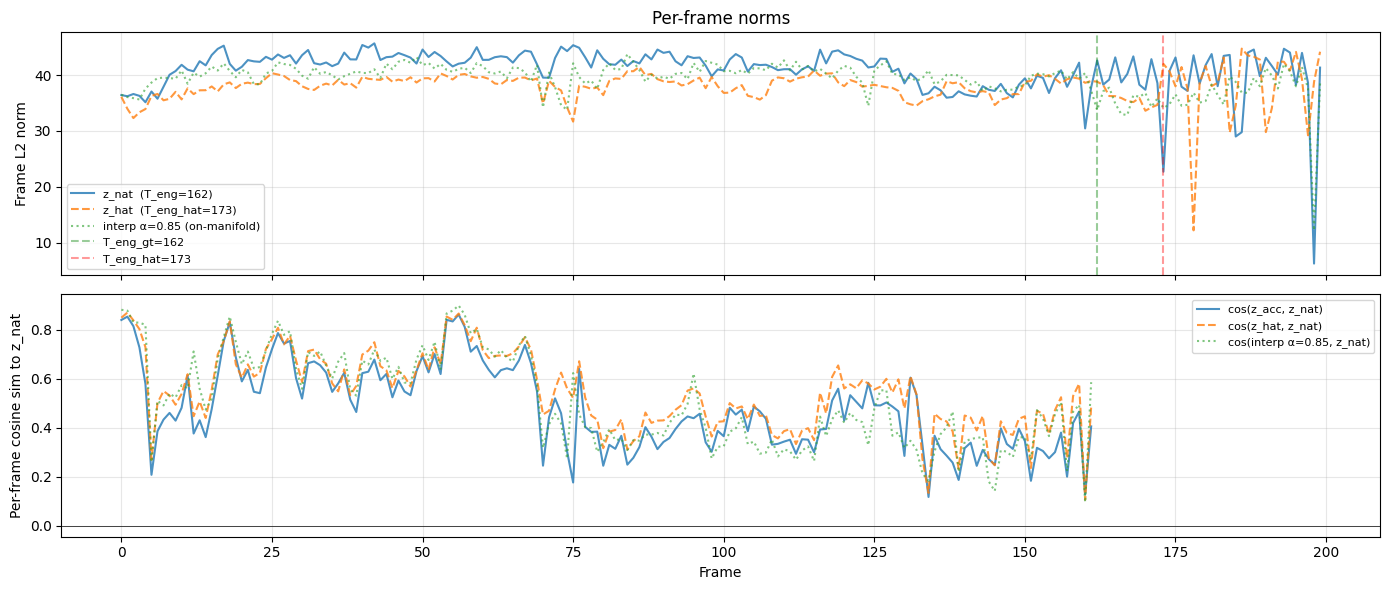

In [9]:
import matplotlib.pyplot as plt

SHOW = 200  # frames to plot

norm_acc = z_acc[:SHOW].norm(dim=-1).numpy()
norm_nat = z_nat[:SHOW].norm(dim=-1).numpy()
norm_hat = z_nat_hat_cpu[:SHOW].norm(dim=-1).numpy()
z_interp_085, _ = make_dtw_interp(0.85, path, z_acc, z_nat, T_l2, T_eng_gt)
norm_interp = z_interp_085[:SHOW].norm(dim=-1).numpy()

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax = axes[0]
# ax.plot(norm_acc,   label=f'z_acc  (T_l2={T_l2})',    alpha=0.8)
ax.plot(norm_nat,   label=f'z_nat  (T_eng={T_eng_gt})', alpha=0.8)
ax.plot(norm_hat,   label=f'z_hat  (T_eng_hat={T_eng_hat})', alpha=0.8, linestyle='--')
ax.plot(norm_interp, label='interp α=0.85 (on-manifold)', alpha=0.6, linestyle=':')
# ax.axvline(T_l2,     color='blue',   linestyle='--', alpha=0.4, label=f'T_l2={T_l2}')
ax.axvline(T_eng_gt, color='green',  linestyle='--', alpha=0.4, label=f'T_eng_gt={T_eng_gt}')
ax.axvline(T_eng_hat,color='red',    linestyle='--', alpha=0.4, label=f'T_eng_hat={T_eng_hat}')
ax.set_ylabel('Frame L2 norm')
ax.set_title('Per-frame norms')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Per-frame cosine sim of z_hat to z_nat
ax2 = axes[1]
N = min(T_eng_gt, T_eng_hat, T_l2)
cos_hat_frame   = torch.nn.functional.cosine_similarity(z_nat_hat_cpu[:N], z_nat[:N], dim=-1).numpy()
cos_acc_frame   = torch.nn.functional.cosine_similarity(z_acc[:N],         z_nat[:N], dim=-1).numpy()
cos_interp_frame= torch.nn.functional.cosine_similarity(
    make_dtw_interp(0.85, path, z_acc, z_nat, T_l2, T_eng_gt)[0][:N], z_nat[:N], dim=-1).numpy()

ax2.plot(cos_acc_frame,    label='cos(z_acc, z_nat)',    alpha=0.8)
ax2.plot(cos_hat_frame,    label='cos(z_hat, z_nat)',    alpha=0.8, linestyle='--')
ax2.plot(cos_interp_frame, label='cos(interp α=0.85, z_nat)', alpha=0.6, linestyle=':')
ax2.axhline(0, color='k', linewidth=0.5)
ax2.set_ylabel('Per-frame cosine sim to z_nat')
ax2.set_xlabel('Frame')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('notebooks/frame_inspection.png', dpi=150)
plt.show()
# print('Saved: notebooks/frame_inspection.png')

## 9. Padding surgery — isolate speech vs tail as the culprit

In [10]:
print(f'Reference: "{PAIR["text"]}"\n')

def attach_acc_silence(speech_z, T_speech, T_l2, z_acc, L=1500):
    """z[:T_speech] from speech_z, then z_acc[T_l2:] silence — tile last frame if short."""
    z = speech_z.clone()
    n_needed = L - T_speech
    n_avail  = L - T_l2
    if n_avail >= n_needed:
        z[T_speech:] = z_acc[T_l2 : T_l2 + n_needed]
    else:
        # T_speech < T_l2: need more silence than available — tile last frame
        z[T_speech : T_speech + n_avail] = z_acc[T_l2:]
        z[T_speech + n_avail :]          = z_acc[-1:].expand(n_needed - n_avail, -1)
    return z

# A: z_hat speech + z_acc silence at T_eng_hat (key test — if this decodes, speech frames are fine)
z_hat_acc_sil = attach_acc_silence(z_nat_hat_cpu, T_eng_hat, T_l2, z_acc)
decode(z_hat_acc_sil, 'z_hat speech + z_acc silence @ T_eng_hat')

# B: z_acc speech + z_acc silence but shifted to T_eng_hat (sanity — should decode)
z_acc_shifted = attach_acc_silence(z_acc, T_eng_hat, T_l2, z_acc)
decode(z_acc_shifted, 'z_acc speech + z_acc silence @ T_eng_hat (sanity)')

# C: on-manifold DTW interp at matched cos_sim — confirms on-manifold decodes at this level
n = min(T_l2, T_eng_gt)
cos_hat = torch.nn.functional.cosine_similarity(
    z_nat_hat_cpu[:n], z_nat[:n], dim=-1).mean().item()
best_alpha, best_diff = 0.5, 1.0
for a in torch.linspace(0, 1, 101):
    z_tmp = a.item() * z_acc[:n] + (1 - a.item()) * z_nat[:n]
    c = torch.nn.functional.cosine_similarity(z_tmp, z_nat[:n], dim=-1).mean().item()
    if abs(c - cos_hat) < best_diff:
        best_diff, best_alpha = abs(c - cos_hat), a.item()
z_matched, N_matched = make_dtw_interp(best_alpha, path, z_acc, z_nat, T_l2, T_eng_gt)
cos_matched = torch.nn.functional.cosine_similarity(z_matched[:n], z_nat[:n], dim=-1).mean().item()
print(f'\nMatched interp: alpha={best_alpha:.2f} → cos={cos_matched:.4f}  (z_hat cos={cos_hat:.4f})')
decode(z_matched, f'on-manifold interp α={best_alpha:.2f} (same cos_sim as z_hat)')


Reference: "Broken Tooth yelled with fright and pain"

[z_hat speech + z_acc silence @ T_eng_hat] " Roe can toot yell with fright and ban."
[z_acc speech + z_acc silence @ T_eng_hat (sanity)] " Broke a tooth yell with fright and ban"

Matched interp: alpha=0.92 → cos=0.4900  (z_hat cos=0.5437)
[on-manifold interp α=0.92 (same cos_sim as z_hat)] " Broke and tut yell with fright and ban"


' Broke and tut yell with fright and ban'

## 10. Multi-native target analysis — mode-averaging hypothesis

The training mapping pairs each L2 utterance with **all three** native speakers (CLB, SLT, RMS).
Because MSE regression minimises the mean of all targets, the model converges to predicting
their **centroid** in latent space rather than any individual speaker.

If the centroid of {CLB, SLT, RMS} sits off the Whisper encoder manifold, the bridge output
will have good cosine similarity to z_nat on paper but be undecoadable.

Key numbers to compare:
- `cos_sim(z_acc, z_nat)` — baseline gap the bridge must close
- `cos_sim(CLB, SLT/RMS) etc.` — spread of the three native targets for the same utterance
- Bridge training diagnostic cos_sim ≈ **0.59** (from history.json)

If the bridge cos_sim ≈ inter-native cos_sim, the model has learned the centroid.

In [11]:
from collections import defaultdict
import torch.nn.functional as F
import numpy as np
import random
import jiwer

TRAIN_DIR = Path(os.environ['TRAIN_DATA_DIR'])

with open('src/experiments/exp2_latent_diffusion_bridge/data/mapping_train.json') as f:
    train_map = json.load(f)

# Group entries by (l2_speaker, prompt_id) → {nat_speaker: entry}
groups = defaultdict(dict)
for u in train_map:
    key = (u['l2_speaker'], u['prompt_id'])
    groups[key][u['nat_speaker']] = u

NATIVE_SPKS = ['CLB', 'SLT', 'RMS']
PAIRS = [('CLB','SLT'), ('CLB','RMS'), ('SLT','RMS')]
triplets = {k: v for k, v in groups.items() if all(s in v for s in NATIVE_SPKS)}
print(f'Complete triplets: {len(triplets):,} / {len(groups):,} utterance keys')

sample = list(triplets.items()); random.shuffle(sample)


Complete triplets: 12,428 / 20,132 utterance keys


In [12]:


inter_nat_sims = {(a, b): [] for a, b in PAIRS}
acc_nat_sims   = {s: [] for s in NATIVE_SPKS}
centroid_sims  = []

import random; random.seed(0)

n_ok = 0
for key, entries in sample[:300]:
    z_nats = {}
    T_nats = {}
    ok = True
    for spk in NATIVE_SPKS:
        p = TRAIN_DIR / entries[spk]['nat_encoder_state_path']
        if not p.exists(): ok = False; break
        z = torch.load(p, map_location='cpu', weights_only=False)
        if isinstance(z, dict): z = z['hidden_states']
        z_nats[spk] = z.float()
        T_nats[spk] = entries[spk]['nat_speech_end_frame']
    if not ok: continue

    e0 = entries[NATIVE_SPKS[0]]
    acc_p = TRAIN_DIR / e0['l2_encoder_state_path']
    if not acc_p.exists(): continue
    z_acc_u = torch.load(acc_p, map_location='cpu', weights_only=False)
    if isinstance(z_acc_u, dict): z_acc_u = z_acc_u['hidden_states']
    z_acc_u = z_acc_u.float()
    T_l2_u = e0['l2_speech_end_frame']

    # Inter-native: compare each pair over min of their two speech lengths
    for (a, b) in PAIRS:
        T_ab = min(T_nats[a], T_nats[b])
        if T_ab < 5: continue
        inter_nat_sims[(a, b)].append(
            F.cosine_similarity(z_nats[a][:T_ab], z_nats[b][:T_ab], dim=-1).mean().item())

    # z_acc vs z_nat: over min of L2 speech and each native speech length
    for spk in NATIVE_SPKS:
        T_an = min(T_l2_u, T_nats[spk])
        if T_an < 5: continue
        acc_nat_sims[spk].append(
            F.cosine_similarity(z_acc_u[:T_an], z_nats[spk][:T_an], dim=-1).mean().item())

    # Centroid: average [0:T_max] across all 3 speakers (speech frames only)
    T_max = max(T_nats.values())
    centroid_speech = torch.stack([z_nats[spk][:T_max] for spk in NATIVE_SPKS]).mean(0)
    for spk in NATIVE_SPKS:
        T_cmp = min(T_nats[spk], T_max)
        centroid_sims.append(
            F.cosine_similarity(centroid_speech[:T_cmp], z_nats[spk][:T_cmp], dim=-1).mean().item())

    n_ok += 1

print(f'Processed {n_ok} utterances\n')

all_inter   = [s for v in inter_nat_sims.values() for s in v]
all_acc_nat = [s for v in acc_nat_sims.values() for s in v]

print('── Inter-native cosine sim (speech frames only) ──')
for (a, b), sims in inter_nat_sims.items():
    print(f'  {a}↔{b}: {np.mean(sims):.4f} ± {np.std(sims):.4f}')
print(f'  overall:  {np.mean(all_inter):.4f} ± {np.std(all_inter):.4f}')

print('\n── z_acc vs z_nat cosine sim (speech frames only) ──')
for spk, sims in acc_nat_sims.items():
    print(f'  z_acc ↔ {spk}: {np.mean(sims):.4f} ± {np.std(sims):.4f}')
print(f'  z_acc ↔ all:  {np.mean(all_acc_nat):.4f} ± {np.std(all_acc_nat):.4f}')

print(f'\n── Centroid cos_sim to each z_nat (speech frames only) ──')
print(f'  {np.mean(centroid_sims):.4f} ± {np.std(centroid_sims):.4f}')

bridge_diagnostic_sim = 0.590
print(f'\n── Bridge training diagnostic cos_sim (from history.json) ──')
print(f'  {bridge_diagnostic_sim:.4f}  (flat across all 15 epochs)')
print(f'\n→ centroid sim = {np.mean(centroid_sims):.4f},  bridge sim = {bridge_diagnostic_sim:.4f}')
print(f'  gap = {abs(np.mean(centroid_sims) - bridge_diagnostic_sim):.4f}')


Processed 153 utterances

── Inter-native cosine sim (speech frames only) ──
  CLB↔SLT: 0.5870 ± 0.0953
  CLB↔RMS: 0.6042 ± 0.0877
  SLT↔RMS: 0.5479 ± 0.0827
  overall:  0.5797 ± 0.0918

── z_acc vs z_nat cosine sim (speech frames only) ──
  z_acc ↔ CLB: 0.5039 ± 0.0778
  z_acc ↔ SLT: 0.4964 ± 0.0626
  z_acc ↔ RMS: 0.5074 ± 0.0701
  z_acc ↔ all:  0.5026 ± 0.0706

── Centroid cos_sim to each z_nat (speech frames only) ──
  0.8484 ± 0.0359

── Bridge training diagnostic cos_sim (from history.json) ──
  0.5900  (flat across all 15 epochs)

→ centroid sim = 0.8484,  bridge sim = 0.5900
  gap = 0.2584


/tmp/ipykernel_1788761/1937089679.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, medianprops=dict(color='k', linewidth=2))


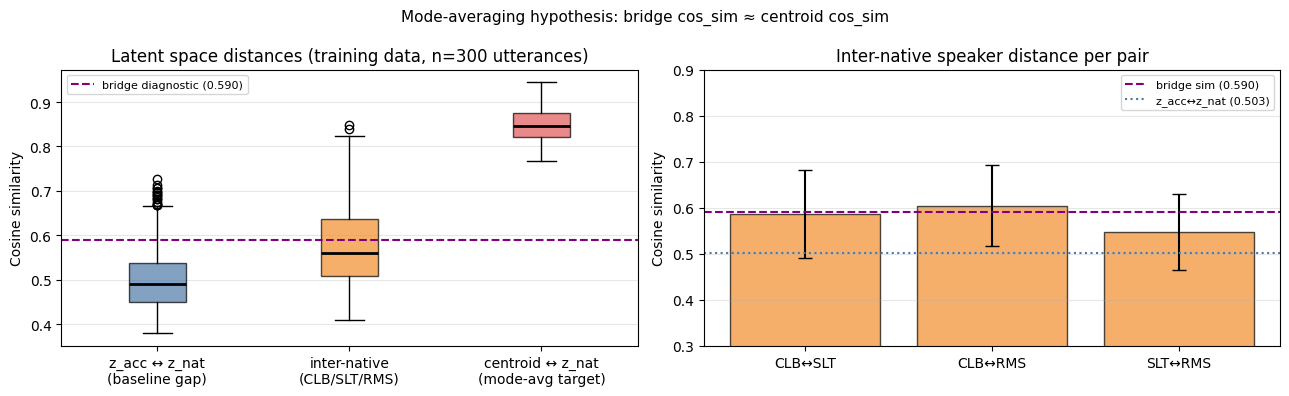

Saved: notebooks/centroid_analysis.png


In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: boxplot of the three sim distributions
ax = axes[0]
data = [all_acc_nat, all_inter, centroid_sims]
labels = ['z_acc ↔ z_nat\n(baseline gap)', 'inter-native\n(CLB/SLT/RMS)', 'centroid ↔ z_nat\n(mode-avg target)']
bp = ax.boxplot(data, labels=labels, patch_artist=True, medianprops=dict(color='k', linewidth=2))
colors = ['#4e79a7', '#f28e2b', '#e15759']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.axhline(bridge_diagnostic_sim, color='purple', linestyle='--', linewidth=1.5,
           label=f'bridge diagnostic ({bridge_diagnostic_sim:.3f})')
ax.set_ylabel('Cosine similarity')
ax.set_title('Latent space distances (training data, n=300 utterances)')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# Right: per-pair inter-native breakdown
ax2 = axes[1]
pair_labels = [f'{a}↔{b}' for a, b in PAIRS]
pair_means  = [np.mean(inter_nat_sims[(a, b)]) for a, b in PAIRS]
pair_stds   = [np.std(inter_nat_sims[(a, b)])  for a, b in PAIRS]
ax2.bar(pair_labels, pair_means, yerr=pair_stds, capsize=5,
        color='#f28e2b', alpha=0.7, edgecolor='k')
ax2.axhline(bridge_diagnostic_sim, color='purple', linestyle='--', linewidth=1.5,
            label=f'bridge sim ({bridge_diagnostic_sim:.3f})')
ax2.axhline(np.mean(all_acc_nat), color='#4e79a7', linestyle=':', linewidth=1.5,
            label=f'z_acc↔z_nat ({np.mean(all_acc_nat):.3f})')
ax2.set_ylabel('Cosine similarity')
ax2.set_title('Inter-native speaker distance per pair')
ax2.set_ylim(0.3, 0.9)
ax2.legend(fontsize=8); ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Mode-averaging hypothesis: bridge cos_sim ≈ centroid cos_sim', fontsize=11)
plt.tight_layout()
plt.savefig('notebooks/centroid_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/centroid_analysis.png')

## 11. Centroid WER — is the mode-averaged latent decodable?

Also checks each individual native speaker for reference.
If centroid decodes well → it's on-manifold and would be a better training target than individual z_nats.
If not → mode averaging is off-manifold regardless.

In [14]:
import jiwer
from transformers.modeling_outputs import BaseModelOutput
from tqdm import tqdm

def whisper_decode(z_full: torch.Tensor) -> str:
    enc_out = BaseModelOutput(last_hidden_state=z_full.unsqueeze(0).to(device))
    with torch.no_grad():
        ids = whisper_model.generate(encoder_outputs=enc_out, language='en',
                                     task='transcribe', temperature=0.0)
    return processor.batch_decode(ids, skip_special_tokens=True)[0].lower().strip()

def corpus_wer(refs, hyps):
    return float(jiwer.process_words(refs, hyps).wer)

# Sample utterances that have all three native speakers
n_eval = min(100, len(sample))
rows = {'CLB': [], 'SLT': [], 'RMS': [], 'centroid': []}
refs = []

print(f'Decoding {n_eval} utterances - individual speakers + centroid ...')
n_done = 0
for key, entries in tqdm(sample[:n_eval * 3], desc='Evaluating'):
    if n_done >= n_eval:
        break

    z_nats_u = {}
    ok = True
    for spk in NATIVE_SPKS:
        p = TRAIN_DIR / entries[spk]['nat_encoder_state_path']
        if not p.exists(): ok = False; break
        z = torch.load(p, map_location='cpu', weights_only=False)
        if isinstance(z, dict): z = z['hidden_states']
        z_nats_u[spk] = z.float()
    if not ok:
        continue

    ref = entries[NATIVE_SPKS[0]]['text'].lower().strip()
    import re; ref = re.sub(r'[^\w\s]', '', ref)

    T_nats_u = {spk: entries[spk]['nat_speech_end_frame'] for spk in NATIVE_SPKS}
    T_max_spk = max(T_nats_u, key=T_nats_u.get)
    T_max_u   = T_nats_u[T_max_spk]
    # Average speech frames [0:T_max], attach silence from longest speaker
    centroid_speech = torch.stack([z_nats_u[spk][:T_max_u] for spk in NATIVE_SPKS]).mean(0)
    centroid_full   = torch.cat([centroid_speech, z_nats_u[T_max_spk][T_max_u:]], dim=0)

    refs.append(ref)
    for spk in NATIVE_SPKS:
        rows[spk].append(whisper_decode(z_nats_u[spk]))
    rows['centroid'].append(whisper_decode(centroid_full))
    n_done += 1

print(f'\nEvaluated {n_done} utterances\n')
print(f'{"Source":>10}  {"WER":>7}  note')
print('-' * 45)
for label in ['CLB', 'SLT', 'RMS', 'centroid']:
    wer = corpus_wer(refs, rows[label])
    note = '<- centroid of all 3' if label == 'centroid' else ''
    print(f'{label:>10}  {wer:>7.3f}  {note}')

print('\nSample predictions (first 5):')
for i in range(min(5, n_done)):
    print(f'  ref:      {refs[i]}')
    for label in ['CLB', 'SLT', 'RMS', 'centroid']:
        print(f'  {label:>8}: {rows[label][i]}')
    print()


Decoding 100 utterances - individual speakers + centroid ...


Evaluating:  12%|█▏        | 36/300 [01:14<09:06,  2.07s/it]


KeyboardInterrupt: 

In [ ]:
from src.experiments.exp2_latent_diffusion_bridge.diffusion import bridge_inference

cfg_bridge = json.loads((Path(BRIDGE_CKPT).parent / 'config.json').read_text())
sigma_max_cfg = cfg_bridge['sigma_max']

bridge_rows = []
n_bridge = 0

for key, entries in sample[:n_eval * 3]:
    if n_bridge >= n_done:
        break
    e0 = entries[NATIVE_SPKS[0]]
    acc_p = TRAIN_DIR / e0['l2_encoder_state_path']
    if not acc_p.exists(): continue
    if not all((TRAIN_DIR / entries[spk]['nat_encoder_state_path']).exists() for spk in NATIVE_SPKS): continue
    z_acc_u = torch.load(acc_p, map_location='cpu', weights_only=False)
    if isinstance(z_acc_u, dict): z_acc_u = z_acc_u['hidden_states']
    T_l2_u  = e0['l2_speech_end_frame']
    T_nat_u = e0['nat_speech_end_frame']
    z_acc_bf = z_acc_u.float().to(device=device, dtype=torch.bfloat16).unsqueeze(0)
    with torch.no_grad():
        z_hat = bridge_inference(
            bridge, z_acc_bf, T_l2=T_l2_u, T_nat=T_nat_u,
            n_steps=N_STEPS, sigma_max=sigma_max_cfg,
            parameterization=bridge.parameterization,
        ).squeeze(0).float().cpu()
    bridge_rows.append(whisper_decode(z_hat))
    n_bridge += 1

print(f'Bridge decoded {n_bridge} utterances (GT T_nat)\n')
print(f'{"Source":>10}  {"WER":>7}')
print('-' * 30)
for label in ['CLB', 'SLT', 'RMS', 'centroid']:
    print(f'{label:>10}  {corpus_wer(refs[:n_bridge], rows[label][:n_bridge]):>7.3f}')
print(f'{"bridge":>10}  {corpus_wer(refs[:n_bridge], bridge_rows):>7.3f}')

print('\nSample predictions (first 5):')
for i in range(min(10, n_bridge)):
    print(f'  ref:      {refs[i]}')
    for label in ['CLB', 'SLT', 'RMS']:
        print(f'  {label:>8}: {rows[label][i]}')
    print(f'  {"centroid":>8}: {rows["centroid"][i]}')
    print(f'  {"bridge":>8}: {bridge_rows[i]}')
    print()


Bridge decoded 100 utterances (GT T_nat)

    Source      WER
------------------------------
       CLB    0.196
       SLT    0.200
       RMS    0.208
  centroid    3.471
    bridge    1.794

Sample predictions (first 5):
  ref:      in a way he is my protege
       CLB: in a way he is my protege.
       SLT: in a way he is my protege.
       RMS: in a way, he is my protege.
  centroid: in a way, he is my protege.
    bridge: in a way, he's my protégé.

  ref:      production is doubling and quadrupling upon itself
       CLB: production is doubling and quadrupling upon itself.
       SLT: production is doubling and quadrupling upon itself.
       RMS: production is doubling and quadrupling upon itself.
  centroid: production is doubling and quadrupling upon itself.
    bridge: production is doubling and quadrupling.

  ref:      already he had begun borrowing from the banks
       CLB: already he had begun borrowing from the banks.
       SLT: already he had begun borrowing from the

In [ ]:
import re

def norm_text(s):
    s = s.lower().strip()
    return re.sub(r'[^\w\s]', '', s)

def utt_wer(ref, hyp):
    if not ref: return 0.0
    return float(jiwer.process_words([norm_text(ref)], [norm_text(hyp)]).wer)

scored = sorted(
    [(utt_wer(refs[i], bridge_rows[i]), refs[i], bridge_rows[i], rows['centroid'][i])
     for i in range(n_bridge)],
    key=lambda x: -x[0]
)

print('=== Worst 10 bridge outputs ===\n')
for wer, ref, bridge_pred, centroid_pred in scored[:10]:
    print(f'  WER={wer:.2f}')
    print(f'  ref:      {ref}')
    print(f'  centroid: {centroid_pred}')
    print(f'  bridge:   {bridge_pred}')
    print()

print('=== Best 10 bridge outputs ===\n')
for wer, ref, bridge_pred, centroid_pred in scored[-10:]:
    print(f'  WER={wer:.2f}')
    print(f'  ref:      {ref}')
    print(f'  centroid: {centroid_pred}')
    print(f'  bridge:   {bridge_pred}')
    print()

n_perfect = sum(1 for w, *_ in scored if w == 0.0)
n_total = len(scored)
print(f'Perfect (WER=0): {n_perfect}/{n_total}  ({100*n_perfect/n_total:.0f}%)')
print(f'WER > 1.0:       {sum(1 for w,*_ in scored if w > 1.0)}/{n_total}')


=== Worst 10 bridge outputs ===

  WER=63.50
  ref:      jack london waikiki beach honolulu oahu
  centroid: jack london, waikiki beach, honolulu, oahu.
  bridge:   fresh cases will be able to walk. they will be able to walk. they will be able to walk. they will be able to walk. they will be able to walk. they will be able to walk. they will be able to walk. they will be able to walk. they will be able to walk. they will be able to walk. they will be able to walk. they will be able to walk. they will be able to walk. they will be able to walk. they will be able to walk. they will be able to walk. they will be able to walk. they will be able to walk. they will be able to walk. they will be able to walk. they will be able to walk. they will be able to walk. they will be able to walk. they will be able to walk. they will be able to walk. they will be able to walk. they will be able to walk. they will be able to walk. they will be able to walk. they will be able to walk. they will be able 

## 12. ODE Trajectory Diagnostics — where does the bridge actually move?

At each ODE step (t: 1→0) track:
- **cos(z_t, z_acc)**: movement away from source
- **cos(z_t, z_nat)**: movement toward target (should rise monotonically if bridge is working)
- **cos(x̃₀, z_nat)**: model's x0 prediction quality at each step
- **direction alignment**: cos(ODE step vector, ideal direction to z_nat) — are we stepping the right way?

Then compare trajectories across good (WER≈0) vs bad (WER>>1) utterances, and project into 2D via PCA.

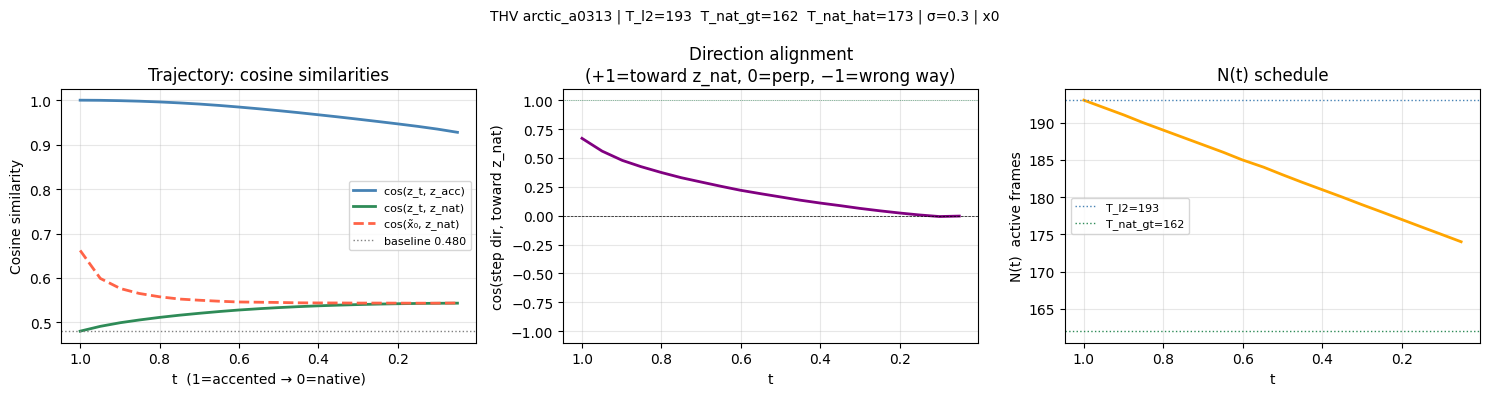

Saved: notebooks/trajectory_single.png


In [12]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Uses z_acc, z_nat, z_acc_bf16, T_l2, T_eng_gt, T_eng_hat, bridge, sigma_max from sections 1-3
T_ref = min(T_l2, T_eng_gt)  # compare over speech frames both speakers share

def speech_cos(a, b, T):
    n = min(T, a.shape[0], b.shape[0])
    return F.cosine_similarity(a[:n].float(), b[:n].float(), dim=-1).mean().item()

B, L, D = z_acc_bf16.shape
dtype    = z_acc_bf16.dtype
inf_len  = max(T_l2, T_eng_hat) + 1
z_acc_crop = z_acc_bf16[:, :inf_len, :]
t_sched    = torch.linspace(1.0, 0.0, N_STEPS + 1, device=device, dtype=dtype)

def apply_mask(z, t_val):
    N_t = max(1, min(round(float(t_val) * T_l2 + (1 - float(t_val)) * T_eng_hat), L))
    sil = torch.arange(T_l2, T_l2 + (L - N_t), device=device).clamp(max=L - 1)
    z[:, N_t:, :] = z_acc_bf16[:, sil, :]
    return z, N_t

is_cfm = bridge.parameterization == 'cfm'
cos_zt_acc, cos_zt_nat, cos_pred_nat, dir_align, n_t_vals, t_vals = [], [], [], [], [], []

z_t = z_acc_bf16.clone()
z_t, _ = apply_mask(z_t, 1.0)

bridge.eval()
with torch.no_grad():
    for i in range(N_STEPS):
        t_cur  = t_sched[i]
        t_next = t_sched[i + 1]
        dt     = (t_cur - t_next).item()
        t_batch = torch.full((B,), t_cur, device=device, dtype=dtype)

        out_crop = bridge(z_t[:, :inf_len, :], t_batch, z_acc_crop)

        if is_cfm:
            # z_hat = next z_t after Euler step; step direction = -v_pred
            z_hat_crop = z_t[:, :inf_len, :] - out_crop * dt
            z_hat_full = z_t.clone(); z_hat_full[:, :inf_len, :] = z_hat_crop
            zt_cpu   = z_t.squeeze(0).float().cpu()
            pred_cpu = z_hat_full.squeeze(0).float().cpu()   # next z_t position
            step_v   = (-out_crop[0].float().cpu()[:T_ref]).reshape(-1)  # -v = step direction
        elif bridge.parameterization == 'x0':
            z_hat_full = z_t.clone(); z_hat_full[:, :inf_len, :] = out_crop
            zt_cpu   = z_t.squeeze(0).float().cpu()
            pred_cpu = z_hat_full.squeeze(0).float().cpu()
            step_v   = (pred_cpu[:T_ref] - zt_cpu[:T_ref]).reshape(-1)
        else:  # eps
            sigma_fwd = sigma_max * torch.sqrt(torch.clamp(t_cur, min=1e-5))
            z_hat_crop = z_t[:, :inf_len, :] - sigma_fwd * out_crop
            z_hat_full = z_t.clone(); z_hat_full[:, :inf_len, :] = z_hat_crop
            zt_cpu   = z_t.squeeze(0).float().cpu()
            pred_cpu = z_hat_full.squeeze(0).float().cpu()
            step_v   = (pred_cpu[:T_ref] - zt_cpu[:T_ref]).reshape(-1)

        ideal_v = (z_nat[:T_ref] - zt_cpu[:T_ref]).reshape(-1)

        cos_zt_acc.append(speech_cos(zt_cpu, z_acc, T_ref))
        cos_zt_nat.append(speech_cos(zt_cpu, z_nat, T_ref))
        cos_pred_nat.append(speech_cos(pred_cpu, z_nat, T_ref))
        dir_align.append(
            F.cosine_similarity(step_v.unsqueeze(0), ideal_v.unsqueeze(0)).item()
            if step_v.norm() > 1e-6 and ideal_v.norm() > 1e-6 else float('nan')
        )
        t_vals.append(t_cur.item())
        n_t_vals.append(max(1, round(float(t_cur) * T_l2 + (1 - float(t_cur)) * T_eng_hat)))

        if i == N_STEPS - 1:
            break

        if is_cfm:
            z_t[:, :inf_len, :] = z_hat_crop
        else:
            z_t = (1 - t_next / t_cur) * z_hat_full + (t_next / t_cur) * z_t
        z_t, _ = apply_mask(z_t, t_next.item())

baseline_sim = speech_cos(z_acc, z_nat, T_ref)
pred_label   = 'cos(z_t−v·dt, z_nat)' if is_cfm else 'cos(x̃₀, z_nat)'
step_label   = 'cos(−v, toward z_nat)' if is_cfm else 'cos(step dir, toward z_nat)'

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.plot(t_vals, cos_zt_acc,   label='cos(z_t, z_acc)',  color='steelblue',  lw=2)
ax.plot(t_vals, cos_zt_nat,   label='cos(z_t, z_nat)',  color='seagreen',   lw=2)
ax.plot(t_vals, cos_pred_nat, label=pred_label,          color='tomato',     lw=2, linestyle='--')
ax.axhline(baseline_sim, color='gray', linestyle=':', lw=1, label=f'baseline {baseline_sim:.3f}')
ax.invert_xaxis()
ax.set_xlabel('t  (1=accented → 0=native)')
ax.set_ylabel('Cosine similarity')
ax.set_title('Trajectory: cosine similarities')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(t_vals, dir_align, color='purple', lw=2)
ax2.axhline(0, color='k', lw=0.5, linestyle='--')
ax2.axhline(1, color='seagreen', lw=0.5, linestyle=':')
ax2.invert_xaxis()
ax2.set_xlabel('t')
ax2.set_ylabel(step_label)
ax2.set_title(f'Direction alignment\n(+1=toward z_nat, 0=perp, −1=wrong way)')
ax2.set_ylim(-1.1, 1.1); ax2.grid(alpha=0.3)

ax3 = axes[2]
ax3.plot(t_vals, n_t_vals, color='orange', lw=2)
ax3.axhline(T_l2,     color='steelblue', linestyle=':', lw=1, label=f'T_l2={T_l2}')
ax3.axhline(T_eng_gt, color='seagreen',  linestyle=':', lw=1, label=f'T_nat_gt={T_eng_gt}')
ax3.invert_xaxis()
ax3.set_xlabel('t')
ax3.set_ylabel('N(t)  active frames')
ax3.set_title('N(t) schedule')
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

plt.suptitle(
    f'{PAIR["l2_speaker"]} {PAIR["l2_utterance_id"]} | '
    f'T_l2={T_l2}  T_nat_gt={T_eng_gt}  T_nat_hat={T_eng_hat} | σ={sigma_max} | {bridge.parameterization}',
    fontsize=10)
plt.tight_layout()
plt.savefig('notebooks/trajectory_single.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/trajectory_single.png')


Traced 25 utterances
WER: min=0.000  median=0.222  max=1.000


/tmp/ipykernel_3566419/4151385901.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


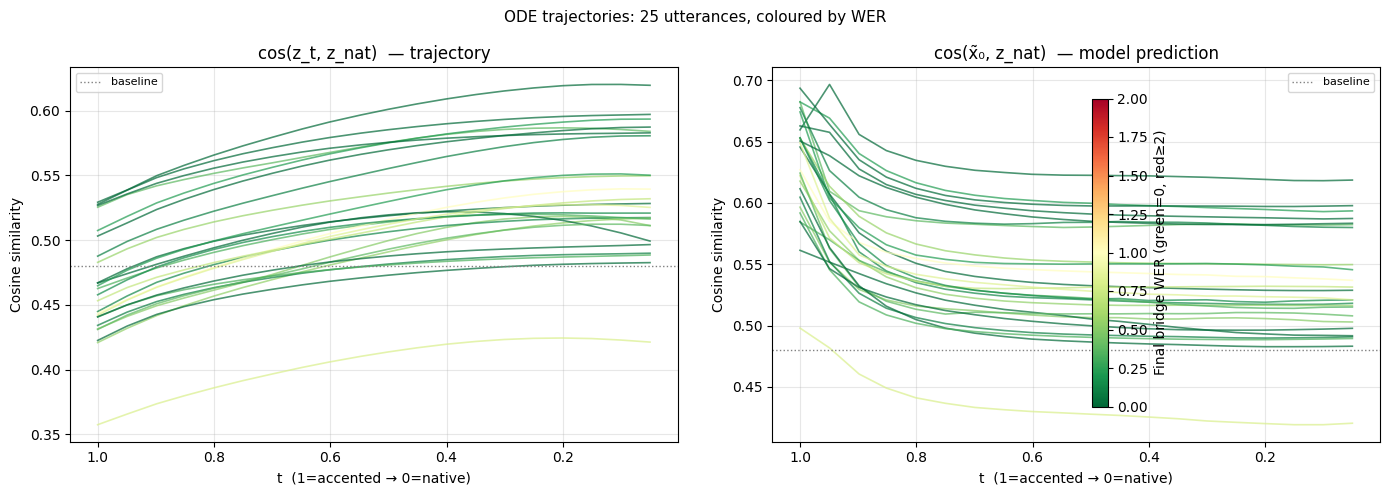

Saved: notebooks/trajectory_multi.png


In [13]:
import matplotlib.cm as cm
import re

# Trace N_TRACE utterances from sample; use GT T_nat for fair comparison.
# Reuses: sample, TRAIN_DIR, NATIVE_SPKS, BRIDGE_CKPT, sigma_max_cfg, whisper_model, processor
N_TRACE = 25

def norm_text(s):
    return re.sub(r'[^\w\s]', '', s.lower().strip())

traj_records = []  # list of {cos_zt_nat, cos_pred_nat, wer, label}

bridge.eval()
for key, entries in sample[:N_TRACE * 5]:
    if len(traj_records) >= N_TRACE:
        break
    e0 = entries[NATIVE_SPKS[0]]
    acc_p = TRAIN_DIR / e0['l2_encoder_state_path']
    nat_p = TRAIN_DIR / entries['CLB']['nat_encoder_state_path']
    if not acc_p.exists() or not nat_p.exists():
        continue

    z_a = torch.load(acc_p, map_location='cpu', weights_only=False)
    z_n = torch.load(nat_p,  map_location='cpu', weights_only=False)
    z_a = (z_a['hidden_states'] if isinstance(z_a, dict) else z_a).float()
    z_n = (z_n['hidden_states'] if isinstance(z_n, dict) else z_n).float()

    Tl2  = e0['l2_speech_end_frame']
    Tnat = entries['CLB']['nat_speech_end_frame']
    Tref = min(Tl2, Tnat)
    if Tref < 20:
        continue

    z_a_dev = z_a.to(device=device, dtype=torch.bfloat16).unsqueeze(0)
    il       = max(Tl2, Tnat) + 1
    z_a_crop = z_a_dev[:, :il, :]
    t_sch    = torch.linspace(1.0, 0.0, N_STEPS + 1, device=device, dtype=torch.bfloat16)

    def _mask(z, tv):
        Nt = max(1, min(round(float(tv) * Tl2 + (1 - float(tv)) * Tnat), 1500))
        sil = torch.arange(Tl2, Tl2 + (1500 - Nt), device=device).clamp(max=1499)
        z[:, Nt:, :] = z_a_dev[:, sil, :]
        return z

    cos_zt = []
    cos_pr = []
    z_t_u  = z_a_dev.clone()
    z_t_u  = _mask(z_t_u, 1.0)

    with torch.no_grad():
        for i in range(N_STEPS):
            tc = t_sch[i]; tn = t_sch[i + 1]
            tb = torch.full((1,), tc, device=device, dtype=torch.bfloat16)
            zp = z_t_u.clone(); zp[:, :il, :] = bridge(z_t_u[:, :il, :], tb, z_a_crop)

            zt_c = z_t_u.squeeze(0).float().cpu()
            zp_c = zp.squeeze(0).float().cpu()
            cos_zt.append(speech_cos(zt_c, z_n, Tref))
            cos_pr.append(speech_cos(zp_c, z_n, Tref))

            if i == N_STEPS - 1:
                break
            z_t_u = (1 - tn / tc) * zp + (tn / tc) * z_t_u
            z_t_u = _mask(z_t_u, tn.item())

    # Decode final output
    from transformers.modeling_outputs import BaseModelOutput
    enc = BaseModelOutput(last_hidden_state=zp.float())
    with torch.no_grad():
        ids = whisper_model.generate(encoder_outputs=enc,
                                     language='en', task='transcribe', temperature=0.0)
    pred = processor.batch_decode(ids, skip_special_tokens=True)[0]
    ref  = norm_text(e0['text'])
    wer  = float(jiwer.process_words([ref], [norm_text(pred)]).wer) if ref else 1.0

    traj_records.append({'cos_zt_nat': cos_zt, 'cos_pred_nat': cos_pr,
                         'wer': wer, 'ref': ref, 'pred': norm_text(pred)})

print(f'Traced {len(traj_records)} utterances')
wers = [r['wer'] for r in traj_records]
print(f'WER: min={min(wers):.3f}  median={sorted(wers)[len(wers)//2]:.3f}  max={max(wers):.3f}')

# Plot: cos(z_t, z_nat) over steps, colored by final WER (green=good, red=bad)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
max_wer = max(wers) if max(wers) > 0 else 1.0
t_ax = [t_sched[i].item() for i in range(N_STEPS)]

for rec in traj_records:
    c = cm.RdYlGn_r(min(rec['wer'] / 2.0, 1.0))   # red=bad, green=good (cap at WER=2)
    axes[0].plot(t_ax, rec['cos_zt_nat'],   color=c, alpha=0.7, lw=1.2)
    axes[1].plot(t_ax, rec['cos_pred_nat'], color=c, alpha=0.7, lw=1.2)

for ax, title in zip(axes, ['cos(z_t, z_nat)  — trajectory', 'cos(x̃₀, z_nat)  — model prediction']):
    ax.invert_xaxis()
    ax.set_xlabel('t  (1=accented → 0=native)')
    ax.set_ylabel('Cosine similarity')
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.axhline(baseline_sim, color='gray', linestyle=':', lw=1, label='baseline')
    ax.legend(fontsize=8)

sm = plt.cm.ScalarMappable(cmap='RdYlGn_r', norm=plt.Normalize(0, 2))
sm.set_array([])
plt.colorbar(sm, ax=axes, label='Final bridge WER (green=0, red≥2)', shrink=0.8)
plt.suptitle(f'ODE trajectories: {len(traj_records)} utterances, coloured by WER', fontsize=11)
plt.tight_layout()
plt.savefig('notebooks/trajectory_multi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/trajectory_multi.png')

PCA explained variance: 0.923


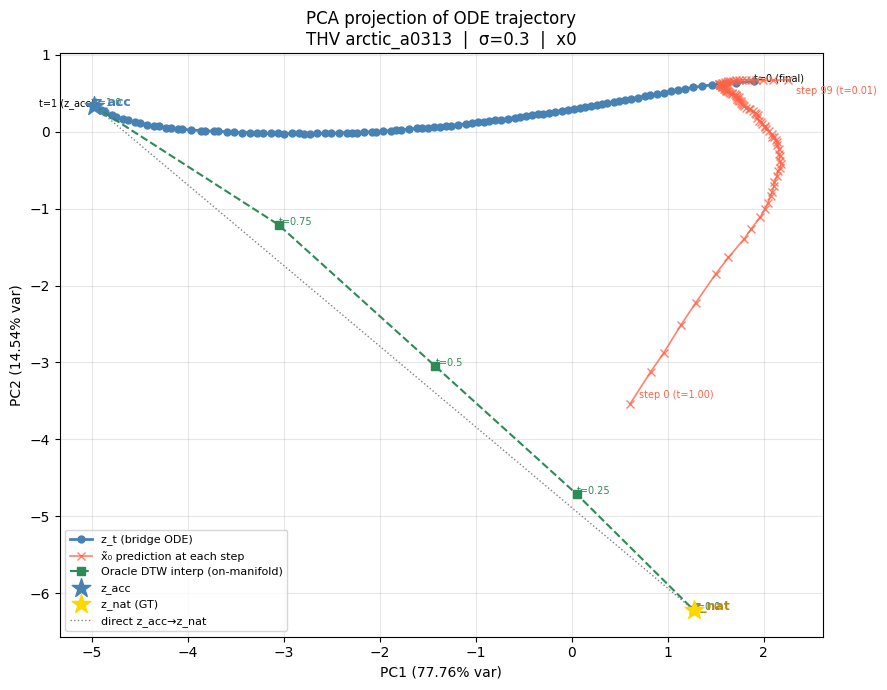

Saved: notebooks/trajectory_pca.png


In [14]:
from sklearn.decomposition import PCA
import numpy as np

B, L, D = z_acc_bf16.shape
dtype    = z_acc_bf16.dtype
inf_len  = max(T_l2, T_eng_hat) + 1
z_acc_crop = z_acc_bf16[:, :inf_len, :]
t_sched    = torch.linspace(1.0, 0.0, 101, device=device, dtype=dtype)

is_cfm = bridge.parameterization == 'cfm'

zt_means   = []   # z_t mean-speech vector at each step (incl. initial t=1)
pred_means = []   # for cfm: next z_t after Euler step; for x0/eps: x0 prediction

z_t = z_acc_bf16.clone()
z_t, _ = apply_mask(z_t, 1.0)
zt_means.append(z_t.squeeze(0).float().cpu()[:T_ref].mean(0).numpy())

bridge.eval()
with torch.no_grad():
    for i in range(100):
        t_cur  = t_sched[i]
        t_next = t_sched[i + 1]
        dt     = (t_cur - t_next).item()
        t_batch = torch.full((B,), t_cur, device=device, dtype=dtype)

        out_crop = bridge(z_t[:, :inf_len, :], t_batch, z_acc_crop)

        if is_cfm:
            z_hat_crop = z_t[:, :inf_len, :] - out_crop * dt
            z_hat_full = z_t.clone(); z_hat_full[:, :inf_len, :] = z_hat_crop
        elif bridge.parameterization == 'x0':
            z_hat_full = z_t.clone(); z_hat_full[:, :inf_len, :] = out_crop
        else:  # eps
            sigma_fwd = sigma_max * torch.sqrt(torch.clamp(t_cur, min=1e-5))
            z_hat_crop = z_t[:, :inf_len, :] - sigma_fwd * out_crop
            z_hat_full = z_t.clone(); z_hat_full[:, :inf_len, :] = z_hat_crop

        pred_means.append(z_hat_full.squeeze(0).float().cpu()[:T_ref].mean(0).numpy())

        if i == 99:
            break

        if is_cfm:
            z_t[:, :inf_len, :] = z_hat_crop
        else:
            z_t = (1 - t_next / t_cur) * z_hat_full + (t_next / t_cur) * z_t
        z_t, _ = apply_mask(z_t, t_next.item())
        zt_means.append(z_t.squeeze(0).float().cpu()[:T_ref].mean(0).numpy())

# Oracle DTW interpolation points
oracle_means = []
for t_val in [1.0, 0.75, 0.5, 0.25, 0.0]:
    z_interp, N_i = make_dtw_interp(t_val, path, z_acc, z_nat, T_l2, T_eng_gt)
    oracle_means.append(z_interp[:min(N_i, T_ref)].mean(0).numpy())

z_acc_mean = z_acc[:T_ref].mean(0).numpy()
z_nat_mean = z_nat[:T_ref].mean(0).numpy()

all_vecs = np.stack(zt_means + pred_means + oracle_means + [z_acc_mean, z_nat_mean])
pca = PCA(n_components=2)
all_2d = pca.fit_transform(all_vecs)
print(f'PCA explained variance: {pca.explained_variance_ratio_[:2].sum():.3f}')

n_zt   = len(zt_means)
n_pred = len(pred_means)
n_orac = len(oracle_means)

zt_2d     = all_2d[:n_zt]
pred_2d   = all_2d[n_zt:n_zt + n_pred]
oracle_2d = all_2d[n_zt + n_pred:n_zt + n_pred + n_orac]
acc_2d    = all_2d[-2]
nat_2d    = all_2d[-1]

pred_line_label = 'z_t−v·dt (next step)' if is_cfm else 'x̃₀ prediction at each step'

fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(zt_2d[:, 0], zt_2d[:, 1], 'o-', color='steelblue', lw=2, ms=5, label='z_t (Euler trajectory)' if is_cfm else 'z_t (bridge ODE)')
ax.annotate('t=1 (z_acc)', zt_2d[0],  fontsize=7, ha='right')
ax.annotate('t=0 (final)', zt_2d[-1], fontsize=7)

ax.plot(pred_2d[:, 0], pred_2d[:, 1], 'x-', color='tomato', lw=1.2, ms=6,
        label=pred_line_label, zorder=5, alpha=0.8)
ax.annotate(f'step 0 (t={t_sched[0].item():.2f})', pred_2d[0],  fontsize=7, color='tomato',
            xytext=(6,  4),  textcoords='offset points')
ax.annotate(f'step 99 (t={t_sched[99].item():.2f})', pred_2d[-1], fontsize=7, color='tomato',
            xytext=(6, -10), textcoords='offset points')

ax.plot(oracle_2d[:, 0], oracle_2d[:, 1], 's--', color='seagreen', lw=1.5, ms=6,
        label='Oracle DTW interp (on-manifold)')
for i, tv in enumerate([1.0, 0.75, 0.5, 0.25, 0.0]):
    ax.annotate(f't={tv}', oracle_2d[i], fontsize=7, color='seagreen')

ax.scatter(*acc_2d, marker='*', s=200, color='steelblue', zorder=6, label='z_acc')
ax.scatter(*nat_2d, marker='*', s=200, color='gold',      zorder=6, label='z_nat (GT)')
ax.annotate('z_acc', acc_2d, fontsize=9, fontweight='bold', color='steelblue')
ax.annotate('z_nat', nat_2d, fontsize=9, fontweight='bold', color='darkgoldenrod')

ax.plot([acc_2d[0], nat_2d[0]], [acc_2d[1], nat_2d[1]], ':', color='gray', lw=1, label='direct z_acc→z_nat')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} var)')
ax.set_title(f'PCA projection of ODE trajectory\n{PAIR["l2_speaker"]} {PAIR["l2_utterance_id"]}  |  σ={sigma_max}  |  {bridge.parameterization}')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('notebooks/trajectory_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/trajectory_pca.png')


  [DTW CFM L2 Timeline] cfm_prewarp  sigma=0.0  100 steps
  [DTW x0 (v2)] x0  sigma=0.3  100 steps
  [DTW x0 +dir] x0  sigma=0.3  100 steps
PCA variance: 0.922


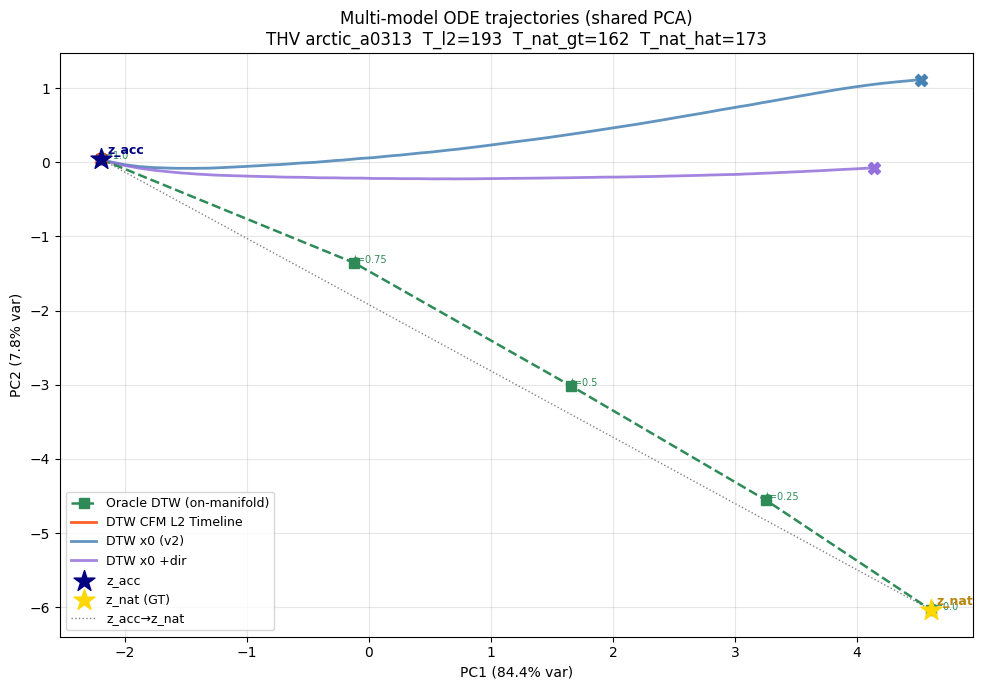

Saved: notebooks/trajectory_pca_compare.png


In [15]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from src.experiments.exp2_latent_diffusion_bridge.eval import load_bridge_model

# ── Configure which models to compare ────────────────────────────────────────
COMPARE_MODELS = [
    # ('models/bridge_dtw_cfm',           'DTW CFM',       'tomato'),
    ('models/bridge_dtw_cfm_prewarp',           'DTW CFM L2 Timeline',       'orangered'),
    ('models/bridge_dtw_v2baseline',     'DTW x0 (v2)',   'steelblue'),
    ('models/bridge_dtw_directionloss',  'DTW x0 +dir',   'mediumpurple'),
    # add/remove entries freely
]
N_ODE_STEPS = 100
# ─────────────────────────────────────────────────────────────────────────────

def run_trajectory(model, parameterization, sigma_mx, z_acc_in, z_acc_crop_in,
                   inf_len, n_steps, T_ref, apply_mask_fn):
    """Collect mean-speech z_t at each ODE step."""
    B, L, D  = z_acc_in.shape
    dtype    = z_acc_in.dtype
    t_sched  = torch.linspace(1.0, 0.0, n_steps + 1, device=device, dtype=dtype)
    is_cfm   = parameterization == 'cfm'

    z_t = z_acc_in.clone()
    z_t, _ = apply_mask_fn(z_t, 1.0)
    means   = [z_t.squeeze(0).float().cpu()[:T_ref].mean(0).numpy()]

    model.eval()
    with torch.no_grad():
        for i in range(n_steps):
            t_cur  = t_sched[i]
            t_next = t_sched[i + 1]
            dt     = (t_cur - t_next).item()
            tb     = torch.full((B,), t_cur, device=device, dtype=dtype)
            out    = model(z_t[:, :inf_len, :], tb, z_acc_crop_in)

            if is_cfm:
                z_hat_crop = z_t[:, :inf_len, :] - out * dt
                z_hat_full = z_t.clone(); z_hat_full[:, :inf_len, :] = z_hat_crop
            elif parameterization == 'x0':
                z_hat_full = z_t.clone(); z_hat_full[:, :inf_len, :] = out
            else:  # eps
                sf = sigma_mx * torch.sqrt(torch.clamp(t_cur, min=1e-5))
                z_hat_crop = z_t[:, :inf_len, :] - sf * out
                z_hat_full = z_t.clone(); z_hat_full[:, :inf_len, :] = z_hat_crop

            if i == n_steps - 1:
                break

            if is_cfm:
                z_t[:, :inf_len, :] = z_hat_crop
            else:
                z_t = (1 - t_next / t_cur) * z_hat_full + (t_next / t_cur) * z_t
            z_t, _ = apply_mask_fn(z_t, t_next.item())
            means.append(z_t.squeeze(0).float().cpu()[:T_ref].mean(0).numpy())

    return means


# ── Oracle DTW path ───────────────────────────────────────────────────────────
oracle_ts    = [1.0, 0.75, 0.5, 0.25, 0.0]
oracle_means = []
for tv in oracle_ts:
    z_interp, N_i = make_dtw_interp(tv, path, z_acc, z_nat, T_l2, T_eng_gt)
    oracle_means.append(z_interp[:min(N_i, T_ref)].mean(0).numpy())

z_acc_mean = z_acc[:T_ref].mean(0).numpy()
z_nat_mean = z_nat[:T_ref].mean(0).numpy()

# ── Run each model ────────────────────────────────────────────────────────────
all_traj = {}
for ckpt_dir, label, color in COMPARE_MODELS:
    cfg_path  = Path(ckpt_dir) / 'config.json'
    ckpt_path = Path(ckpt_dir) / 'checkpoint_best.pt'
    if not ckpt_path.exists():
        print(f'[skip] {label}: no checkpoint at {ckpt_path}')
        continue
    cfg      = json.loads(cfg_path.read_text())
    param    = cfg['parameterization']
    sigma_mx = cfg['sigma_max']
    inf_len_l = max(T_l2, T_eng_hat) + 1

    m = load_bridge_model(str(ckpt_path), device)

    def _mask(z, tv, _tl2=T_l2, _tnat=T_eng_hat, _L=z_acc_bf16.shape[1]):
        Nt  = max(1, min(round(float(tv) * _tl2 + (1 - float(tv)) * _tnat), _L))
        sil = torch.arange(_tl2, _tl2 + (_L - Nt), device=device).clamp(max=_L - 1)
        z[:, Nt:, :] = z_acc_bf16[:, sil, :]
        return z, Nt

    traj = run_trajectory(m, param, sigma_mx, z_acc_bf16.clone(),
                          z_acc_bf16[:, :inf_len_l, :], inf_len_l,
                          N_ODE_STEPS, T_ref, _mask)
    all_traj[label] = traj
    print(f'  [{label}] {param}  sigma={sigma_mx}  {len(traj)} steps')

# ── Fit shared PCA ────────────────────────────────────────────────────────────
all_vecs = [v for traj in all_traj.values() for v in traj] + oracle_means + [z_acc_mean, z_nat_mean]
pca      = PCA(n_components=2)
all_2d   = pca.fit_transform(np.stack(all_vecs))
print(f'PCA variance: {pca.explained_variance_ratio_[:2].sum():.3f}')

idx, traj_2d = 0, {}
for label, traj in all_traj.items():
    traj_2d[label] = all_2d[idx: idx + len(traj)]; idx += len(traj)
oracle_2d = all_2d[idx: idx + len(oracle_means)]
acc_2d    = all_2d[-2]
nat_2d    = all_2d[-1]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(oracle_2d[:, 0], oracle_2d[:, 1], 's--', color='seagreen', lw=1.8, ms=7,
        label='Oracle DTW (on-manifold)', zorder=3)
for i, tv in enumerate(oracle_ts):
    ax.annotate(f't={tv}', oracle_2d[i], fontsize=7, color='seagreen')

color_map = {label: color for _, label, color in COMPARE_MODELS}
for label, pts in traj_2d.items():
    c = color_map.get(label, 'gray')
    ax.plot(pts[:, 0], pts[:, 1], '-', color=c, lw=2, label=label, alpha=0.85)
    ax.scatter(*pts[0],  marker='o', s=55, color=c, zorder=5)
    ax.scatter(*pts[-1], marker='X', s=75, color=c, zorder=5)

ax.scatter(*acc_2d, marker='*', s=250, color='navy', zorder=6, label='z_acc')
ax.scatter(*nat_2d, marker='*', s=250, color='gold', zorder=6, label='z_nat (GT)')
ax.annotate('z_acc', acc_2d, fontsize=9, fontweight='bold', color='navy',
            xytext=(4, 4), textcoords='offset points')
ax.annotate('z_nat', nat_2d, fontsize=9, fontweight='bold', color='darkgoldenrod',
            xytext=(4, 4), textcoords='offset points')
ax.plot([acc_2d[0], nat_2d[0]], [acc_2d[1], nat_2d[1]], ':', color='gray',
        lw=1, label='z_acc→z_nat')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax.set_title(
    f'Multi-model ODE trajectories (shared PCA)\n'
    f'{PAIR["l2_speaker"]} {PAIR["l2_utterance_id"]}  '
    f'T_l2={T_l2}  T_nat_gt={T_eng_gt}  T_nat_hat={T_eng_hat}'
)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('notebooks/trajectory_pca_compare.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/trajectory_pca_compare.png')


In [16]:
import json
import torch
import torch.nn.functional as F
from pathlib import Path

# Load a second utterance for the wrong-utt test
dev_mapping = json.load(open('src/experiments/exp2_latent_diffusion_bridge/data/mapping_dev_v2.json'))
other_entry = next(e for e in dev_mapping if e['l2_utterance_id'] != PAIR['l2_utterance_id'])
other_path  = Path(os.environ['TRAIN_DATA_DIR']) / other_entry['l2_encoder_state_path']
z_acc_other_raw  = torch.load(other_path, map_location='cpu', weights_only=False)
z_acc_other_bf16 = z_acc_other_raw['hidden_states'].to(device=device, dtype=torch.bfloat16).unsqueeze(0)
print(f"Other utterance: {other_entry['l2_utterance_id']}  T_l2={other_entry['l2_speech_end_frame']}")
print(f"This utterance:  {PAIR['l2_utterance_id']}           T_l2={T_l2}")

# Fixed z_acc conditioning for all runs
inf_len    = max(T_l2, T_eng_hat) + 1
z_acc_crop = z_acc_bf16[:, :inf_len, :]

def run_inference_with_z_t_init(z_t_init):
    """Run bridge ODE with custom initial z_t, keeping z_acc conditioning fixed."""
    z_t = z_t_init.clone().to(device=device, dtype=torch.bfloat16)
    if z_t.dim() == 2:
        z_t = z_t.unsqueeze(0)
    t_schedule = torch.linspace(1.0, 0.0, N_STEPS + 1, device=device, dtype=torch.bfloat16)
    bridge.eval()
    with torch.no_grad():
        for i in range(N_STEPS):
            t_cur  = t_schedule[i]
            t_next = t_schedule[i + 1]
            t_batch = torch.full((1,), t_cur, device=device, dtype=torch.bfloat16)
            z_pred_crop = bridge(z_t[:, :inf_len, :], t_batch, z_acc_crop)
            z_nat_hat = z_t.clone()
            z_nat_hat[:, :inf_len, :] = z_pred_crop
            if i == N_STEPS - 1:
                break
            z_t = (1 - t_next / t_cur) * z_nat_hat + (t_next / t_cur) * z_t
    return z_nat_hat.squeeze(0).float().cpu()  # [1500, 768]

def speech_cos(a, b, T):
    n = min(T, a.shape[0], b.shape[0])
    return F.cosine_similarity(a[:n], b[:n], dim=-1).mean().item()

T_ref = min(T_l2, T_eng_gt)

z_hat_normal    = run_inference_with_z_t_init(z_acc_bf16)
z_hat_random    = run_inference_with_z_t_init(torch.randn_like(z_acc_bf16))
z_hat_wrong_utt = run_inference_with_z_t_init(z_acc_other_bf16)

print()
print('=== z_t sensitivity test ===')
print('If model uses z_t:    random/wrong outputs should DIVERGE from normal')
print('If model ignores z_t: all three outputs should be ~identical\n')
print(f'{"run":<22}  {"vs normal":>10}  {"vs z_nat":>10}')
print('-' * 48)
r_rn = speech_cos(z_hat_random,    z_hat_normal, T_ref)
r_wn = speech_cos(z_hat_wrong_utt, z_hat_normal, T_ref)
print(f'{"normal":<22}  {1.0:>10.4f}  {speech_cos(z_hat_normal, z_nat, T_ref):>10.4f}')
print(f'{"random z_t":<22}  {r_rn:>10.4f}  {speech_cos(z_hat_random,    z_nat, T_ref):>10.4f}')
print(f'{"wrong utterance":<22}  {r_wn:>10.4f}  {speech_cos(z_hat_wrong_utt, z_nat, T_ref):>10.4f}')
print()
print('Verdict:')
print(f'  random z_t vs normal    = {r_rn:.4f}  {"-> IGNORES z_t" if r_rn > 0.98 else "-> uses z_t"}')
print(f'  wrong_utt z_t vs normal = {r_wn:.4f}  {"-> IGNORES z_t" if r_wn > 0.98 else "-> uses z_t"}')


Other utterance: arctic_a0031  T_l2=123
This utterance:  arctic_a0313           T_l2=193

=== z_t sensitivity test ===
If model uses z_t:    random/wrong outputs should DIVERGE from normal
If model ignores z_t: all three outputs should be ~identical

run                      vs normal    vs z_nat
------------------------------------------------
normal                      1.0000      0.5440
random z_t                  0.1368      0.1430
wrong utterance             0.3619      0.3744

Verdict:
  random z_t vs normal    = 0.1368  -> uses z_t
  wrong_utt z_t vs normal = 0.3619  -> uses z_t
